In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
import time
import gymnasium as gym
from datetime import datetime
from pathlib import Path
from pyvirtualdisplay import Display
from scipy import ndimage

import sys, os
sys.path.append(str(Path(os.getcwd()).parent))

from src.model.e2c import ConvE2C
from src.dataset import E2CDataset
from src.model.loss import RSSMLoss
from src.model.rssm import RSSME2C
from src.utils import set_seed, anim_frames
from src.eval import Plotter, Evaluator
from src.data_gen.gen_gym import process_image, name_to_env, env_to_aspace

In [17]:
# Parameters
TIME_HORIZON = 5    # How many timesteps to predict into future

yaml_to_load_from = Path(os.getcwd()).parent / "runs/reacher/reacher_510k_0/config.yaml"
model_checkpoint = yaml_to_load_from.parent / "model.pt"
with open(yaml_to_load_from, "r") as f:
    config = yaml.safe_load(f)
device = torch.device(config['train']['device'])
if 'cuda' in config['train']['device']: 
    assert torch.cuda.is_available(), f"{config['train']['device']} selected in config, but is unavailable!"
# Load model
config['vae']['in_image_shape'] = [9, 64, 64]
num_out_channels = config['vae']['in_image_shape'][0] // config['trans']['past_length']    # Output only single frame
config['vae']['out_image_shape'] = (num_out_channels, *config['vae']['in_image_shape'][1:])     
config['trans']['control_size'] = (2)
model = RSSME2C(
    enc_latent_size=config['vae']['enc_latent_size'],
    stochastic_size=config['trans']['stochastic_size'],
    deterministic_size=config['trans']['deterministic_size'],
    control_size=config['trans']['control_size'],
    past_length=config['trans']['past_length'],
    pred_length=config['trans']['pred_length'],
    conv_params=config['vae'],
    device=device,
    output_uncertainty=(config['loss']['loss_type'] == 'uncertainty' or 'rssm' in config['loss']['loss_type'])
)
model.to(device)
state_dict = torch.load(model_checkpoint, map_location=device)
model.load_state_dict(state_dict)
model.eval()
print("Model loaded.")

Model loaded.


/tmp/ipykernel_3059240/378015603.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_checkpoint, map_location=device)


In [18]:
# Create virtual display for running on server
disp = Display(visible=0, size=(480, 480))
disp.start()

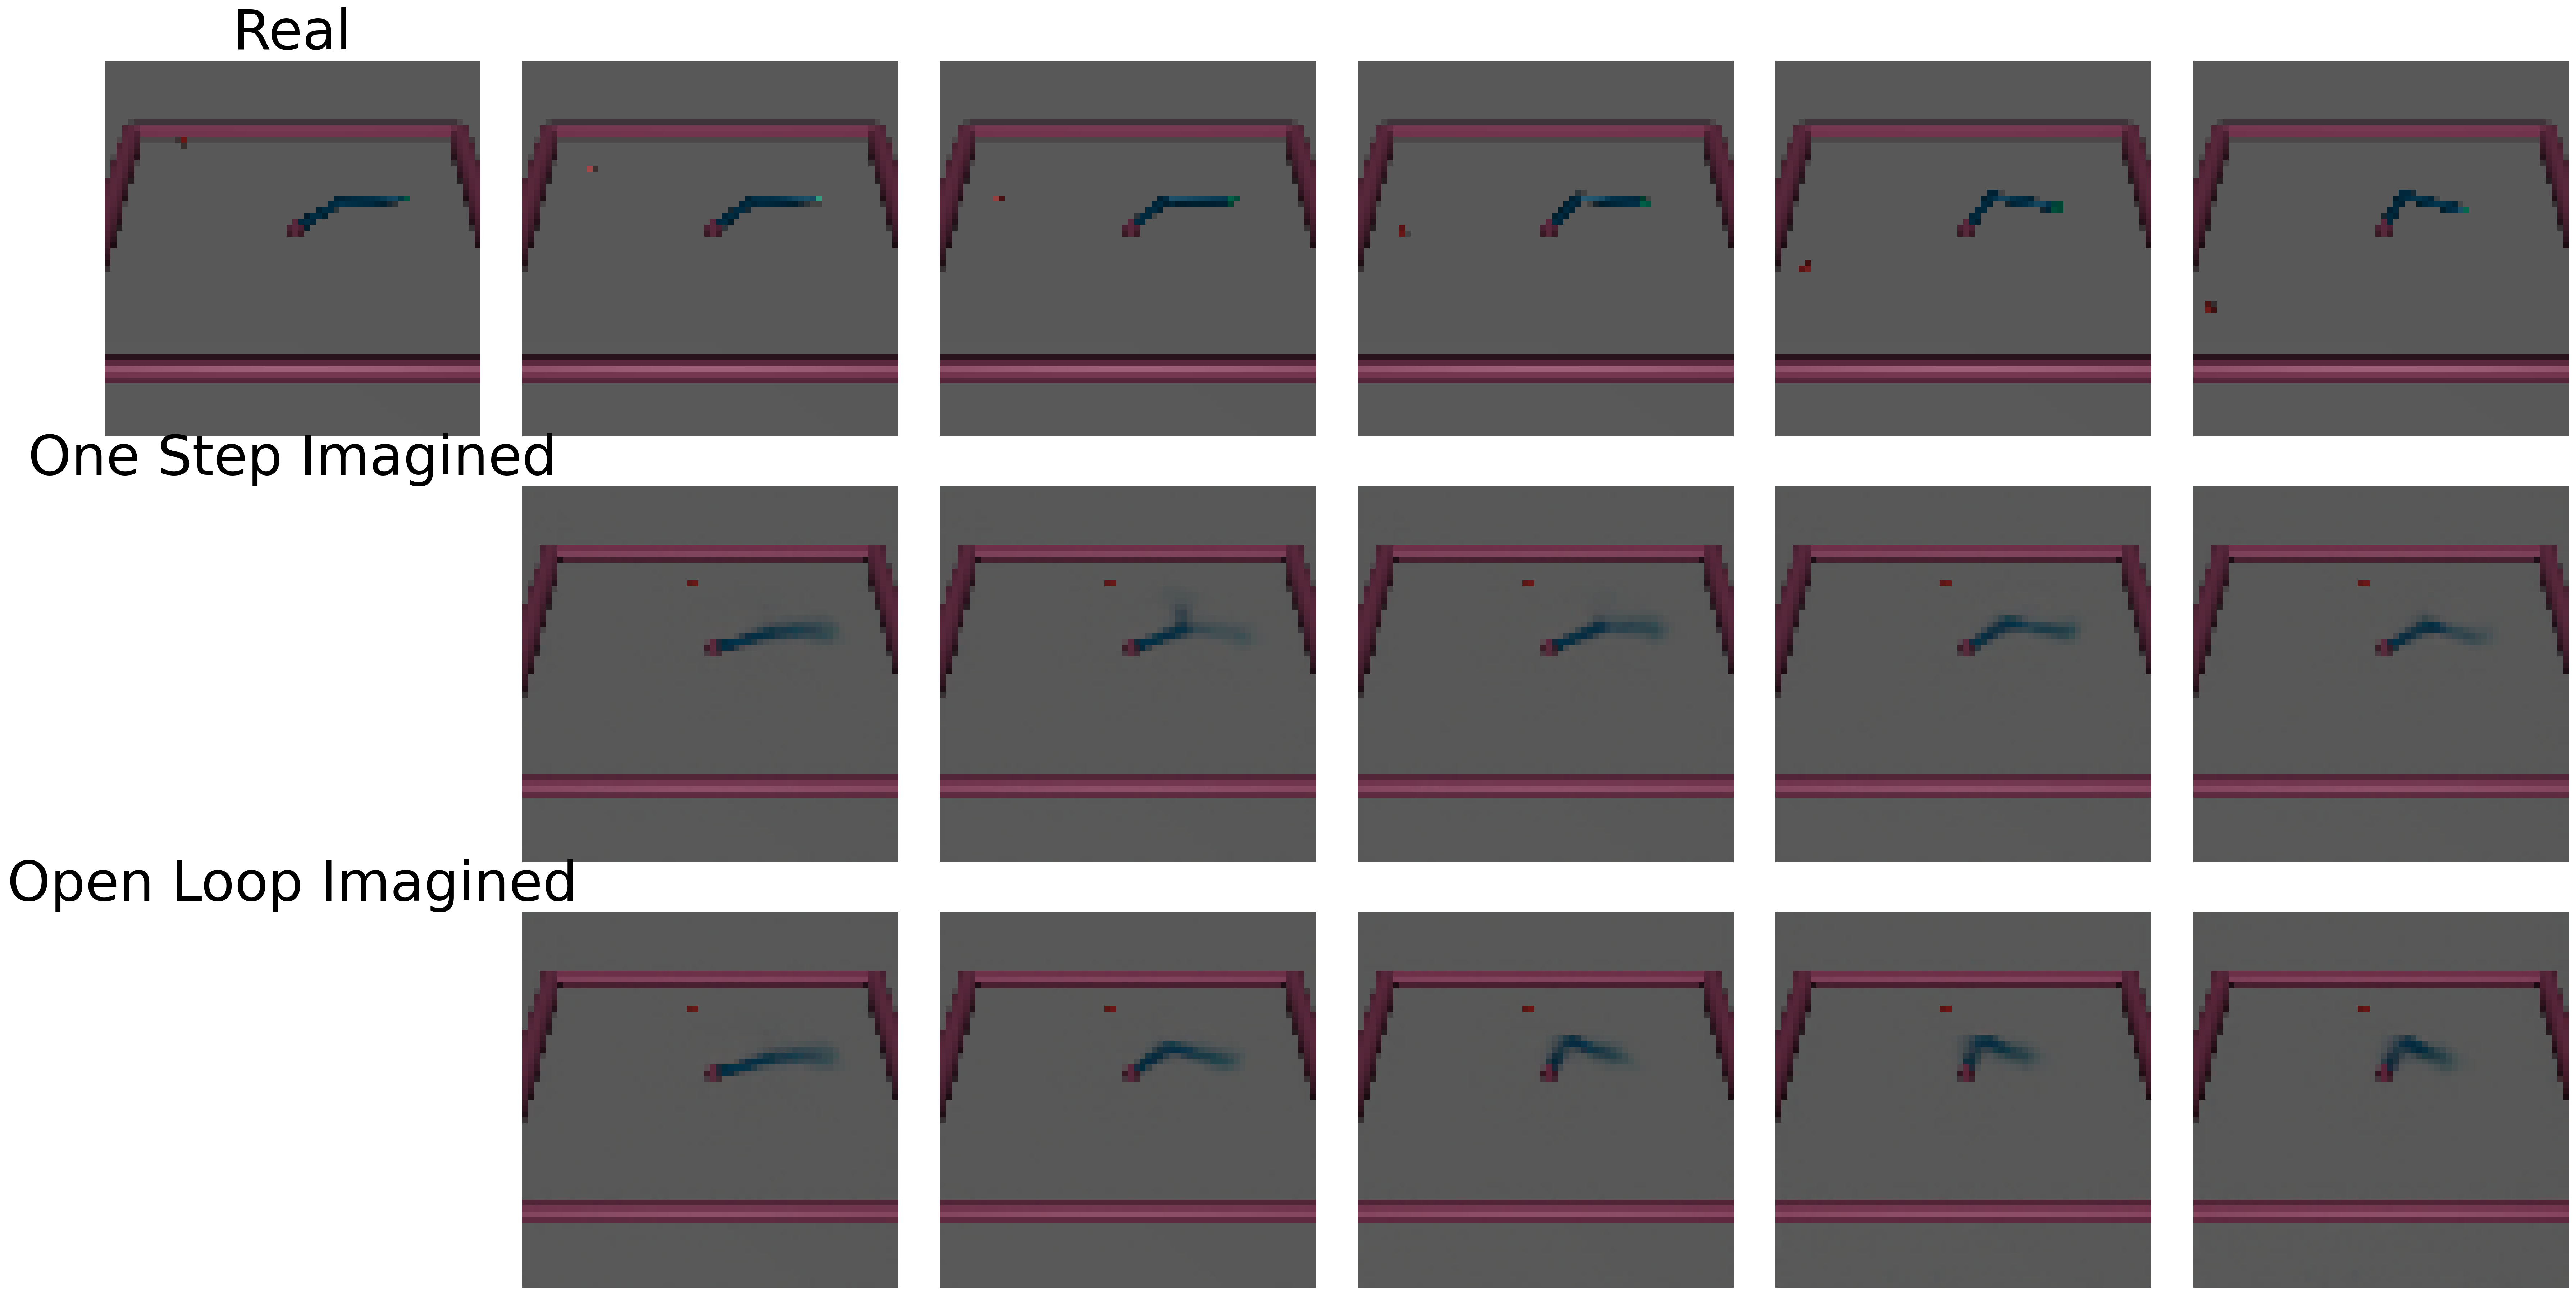

In [20]:
fig, axes = plt.subplots(
    3, TIME_HORIZON + 1,
    figsize=(TIME_HORIZON * 7, 18),
    dpi=200,
    tight_layout=True,
    sharex=True,
    sharey=True
)

for ax in axes.flatten():
    ax.set_aspect('equal')
    ax.axis('off')

fontsize = 55
axes[0, 0].set_title('Real', fontsize=fontsize)
axes[1, 0].set_title('One Step Imagined', fontsize=fontsize)
axes[2, 0].set_title('Open Loop Imagined', fontsize=fontsize)

for t in range(TIME_HORIZON + 1):
    axes[0, t].set_ylabel(f'Timestep {t}', fontsize=fontsize)

# Environment
env_name = config['train']['dataset'].split('_')[0]
env = gym.make(name_to_env[env_name], render_mode="rgb_array")
obs, _ = env.reset()
env.unwrapped.set_state(
    qpos=np.random.uniform(-1.0, 1.0, size=env.unwrapped.model.nq),
    qvel=np.random.uniform(-1.0, 1.0, size=env.unwrapped.model.nv)
)

# Build initial history buffer
past_length = config['trans']['past_length']
pred_length = config['trans']['pred_length']
C, H, W = 3, 64, 64

img_source = torch.zeros(
    (past_length + TIME_HORIZON, C, H, W),
    device=device
)

# Collct observation history
for i in range(past_length):
    action = env.action_space.sample()
    obs, _, _, _, _ = env.step(action)
    img = env.render()

    img_source[i] = (
        process_image(img, config['train']['dataset'])
        .squeeze()
        .permute(2, 0, 1)
        .to(device)
    )

# Initial real frame
axes[0, 0].imshow(
    process_image(img, config['train']['dataset']).squeeze()
)

# Roll out environment + collect controls
all_controls = torch.zeros(
    (TIME_HORIZON, config['trans']['control_size']),
    device=device
)

for t in range(TIME_HORIZON):
    action = env.action_space.sample()
    all_controls[t] = torch.tensor(action, device=device)

    obs, _, _, _, _ = env.step(action)
    img = env.render()

    axes[0, t + 1].imshow(
        process_image(img, config['train']['dataset']).squeeze()
    )

    # slide window
    img_source[t : t + past_length] = img_source[t : t + past_length].clone()
    img_source[past_length + t] = (
        process_image(img, config['train']['dataset'])
        .squeeze()
        .permute(2, 0, 1)
        .to(device)
    )

# Prepare encoder input
x0 = img_source[:past_length]
x0 = x0.reshape(1, past_length * C, H, W)

# One-step imagined
with torch.no_grad():
    for t in range(TIME_HORIZON):
        # Build input of length past_length, last frame is ground truth at time t
        x_input = img_source[t : t + past_length]
        x_input = x_input.reshape(1, past_length * C, H, W)

        # Predict next frame using the current action
        _, x_pred = model.sample(x_input, all_controls[t:t+1])

        # Plot predicted frame
        axes[1, t + 1].imshow(
            x_pred.squeeze(0).permute(1, 2, 0).cpu()
        )

# Open-loop imagined (RSSM prior)
with torch.no_grad():
    imagined = model.sample_traj(
        x0.squeeze(0),
        all_controls
    )

# Handle both CHW and HWC outputs
if imagined.dim() == 4 and imagined.shape[1] == 3:
    imagined = imagined.permute(0, 2, 3, 1)

for t in range(1, TIME_HORIZON + 1):
    axes[2, t].imshow(imagined[t].cpu())

plt.show()